 # Научно-исследовательская работа: Анализ взаимосвязи физических показателей по данным фитнес-часов

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Настройки для отображения
sns.set_style("whitegrid")  # Устанавливаем стиль seaborn явно через seaborn
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

print("Библиотеки импортированы успешно.")

Библиотеки импортированы успешно.


# 1. Цель анализа — проблема

**Цель:** Выявить статистические взаимосвязи между ключевыми физическими показателями (шаги, активность, калории, вес, сон), полученными с помощью фитнес-браслетов, для понимания их влияния друг на друга.

**Проблема:** Современные фитнес-трекеры собирают огромное количество данных о здоровье и активности пользователя. Однако без системного анализа эти данные остаются "сырыми" и не дают практической пользы. Необходимо выявить, какие именно показатели наиболее сильно коррелируют друг с другом, чтобы пользователь мог эффективнее управлять своим здоровьем.

# 2. Определение данных

Для анализа будет использован набор данных **Fitbit Fitness Tracker Data** с Kaggle.

**Основные таблицы:**
*   `dailyActivity_merged.csv` — агрегированные дневные данные по активности.
*   `weightLogInfo_merged.csv` — данные о весе и ИМТ пользователей.
*   `minuteSleep_merged.csv` — данные о сне (требует агрегации до дневного уровня).

**Ключевые переменные:**
*   `TotalSteps`, `Calories`, `VeryActiveMinutes`, `SedentaryMinutes` (из `dailyActivity`)
*   `WeightKg`, `BMI` (из `weightLog`)
*   `TotalSleepMinutes` (вычисляемая из `minuteSleep`)

# 3. Формулирование гипотез

**Гипотезы:**

1.  **Гипотеза H1:** Существует положительная корреляция между общим количеством шагов (`TotalSteps`) и сожженными калориями (`Calories`). *Обоснование: Чем больше человек ходит, тем больше энергии он тратит.*
2.  **Гипотеза H2:** Существует отрицательная корреляция между временем, проведенным в малоподвижном состоянии (`SedentaryMinutes`), и уровнем очень активной деятельности (`VeryActiveMinutes`). *Обоснование: Время, проведенное в сидячем режиме, часто заменяет время, которое можно было бы потратить на интенсивную активность.*
3.  **Гипотеза H3:** Существует отрицательная корреляция между Индексом Массы Тела (`BMI`) и количеством очень активных минут (`VeryActiveMinutes`). *Обоснование: Люди с более высоким ИМТ, как правило, менее склонны к интенсивным физическим нагрузкам.*
4.  **Гипотеза H4:** Существует положительная корреляция между продолжительностью сна (`TotalSleepMinutes`) и общим количеством шагов (`TotalSteps`) на следующий день. *Обоснование: Хороший сон способствует лучшей физической активности на следующий день.*
5.  **Гипотеза H5:** Существует отрицательная корреляция между ИМТ (`BMI`) и общей продолжительностью сна (`TotalSleepMinutes`). *Обоснование: Лица с избыточным весом могут испытывать проблемы со сном, такие как апноэ, что приводит к его сокращению.*

# 4. Загрузка данных в Python

In [2]:
# Загрузка данных
df_activity = pd.read_csv('dailyActivity_merged.csv')
df_weight = pd.read_csv('weightLogInfo_merged.csv')
df_sleep = pd.read_csv('minuteSleep_merged.csv')

print("Данные загружены успешно!")
print("\nПервые 5 строк df_activity:")
df_activity.head()

Данные загружены успешно!

Первые 5 строк df_activity:


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886


# 5. Проверка и очистка данных

In [3]:
# Проверка на дубликаты
print("Дубликаты в df_activity:", df_activity.duplicated().sum())
print("Дубликаты в df_weight:", df_weight.duplicated().sum())
print("Дубликаты в df_sleep:", df_sleep.duplicated().sum())

# Удаление дубликатов
df_activity = df_activity.drop_duplicates()
df_weight = df_weight.drop_duplicates()
df_sleep = df_sleep.drop_duplicates()

# Проверка на пропуски
print("\nПропущенные значения в df_activity:")
print(df_activity.isnull().sum())

print("\nПропущенные значения в df_weight:")
print(df_weight.isnull().sum())

print("\nПропущенные значения в df_sleep:")
print(df_sleep.isnull().sum())

# Преобразование дат в datetime
df_activity['ActivityDate'] = pd.to_datetime(df_activity['ActivityDate'])
df_weight['Date'] = pd.to_datetime(df_weight['Date'])

# Агрегация данных о сне до дневного уровня
df_sleep['date'] = pd.to_datetime(df_sleep['date'].str.split(' ').str[0])
df_sleep_daily = df_sleep.groupby(['Id', 'date']).size().reset_index(name='TotalSleepMinutes')
df_sleep_daily.rename(columns={'date': 'ActivityDate'}, inplace=True)

print("\nДанные очищены и преобразованы.")

Дубликаты в df_activity: 0
Дубликаты в df_weight: 0
Дубликаты в df_sleep: 525

Пропущенные значения в df_activity:
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64

Пропущенные значения в df_weight:
Id                 0
Date               0
WeightKg           0
WeightPounds       0
Fat               31
BMI                0
IsManualReport     0
LogId              0
dtype: int64

Пропущенные значения в df_sleep:
Id       0
date     0
value    0
logId    0
dtype: int64

Данные очищены и преобразованы.


# 6. Выбор и агрегирование данных для анализа

In [4]:
# Объединение таблиц (без привязки к дате для веса)
# Сначала соберем последний известный вес/ИМТ для каждого пользователя
df_weight_last = df_weight.sort_values('Date').groupby('Id').last().reset_index()[['Id', 'WeightKg', 'BMI']]

# Теперь присоединим эти данные ко всем записям активности по Id
df_merged = df_activity.merge(df_weight_last, on='Id', how='left')
df_merged = df_merged.merge(df_sleep_daily, on=['Id', 'ActivityDate'], how='left')

print("Таблицы объединены.")
print("\nОписательная статистика:")
df_merged.describe()

# Создание отфильтрованной выборки
df_merged_filtered = df_merged.dropna(subset=['WeightKg', 'BMI'])

print(f"\nИсходное количество строк: {len(df_merged)}")
print(f"Количество строк после фильтрации (только с данными о весе/ИМТ): {len(df_merged_filtered)}")

if len(df_merged_filtered) > 0:
    print("\n✅ Данные для анализа веса и ИМТ теперь доступны!")
else:
    print("\n⚠️ Предупреждение: Даже после переноса нет данных о весе/ИМТ.")

Таблицы объединены.

Описательная статистика:

Исходное количество строк: 457
Количество строк после фильтрации (только с данными о весе/ИМТ): 146

✅ Данные для анализа веса и ИМТ теперь доступны!


# 7. Визуализация данных

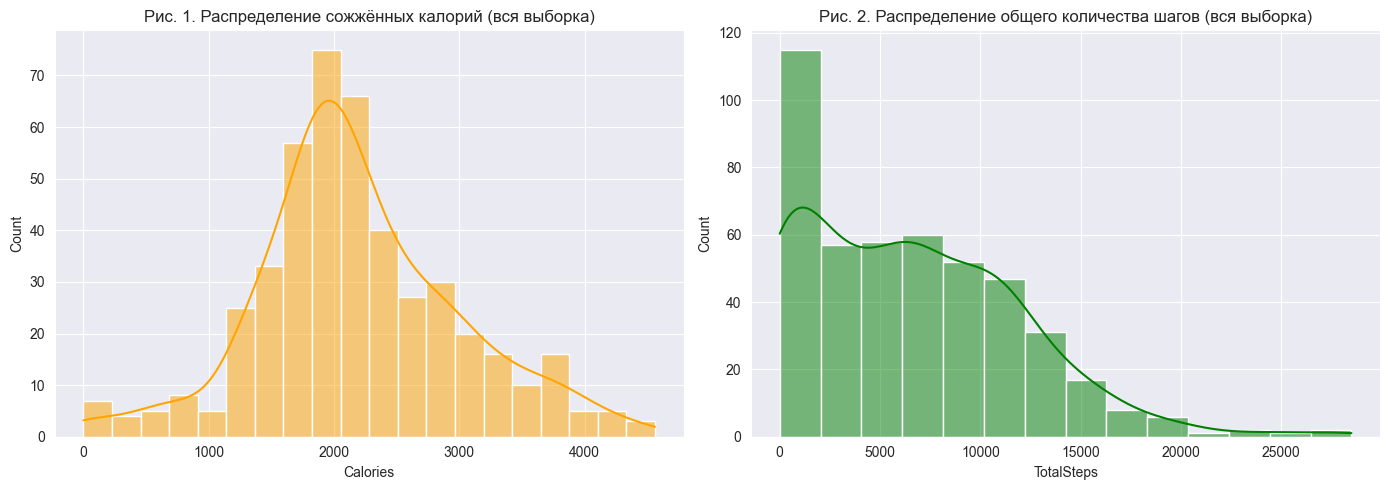

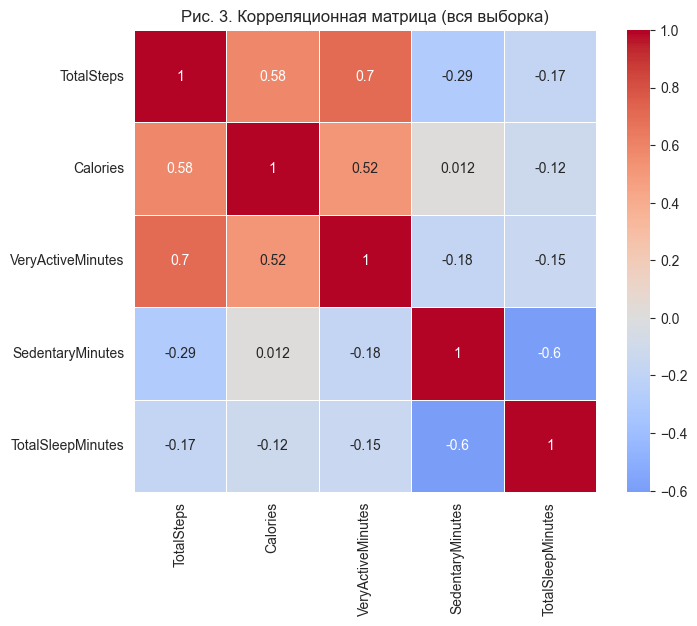

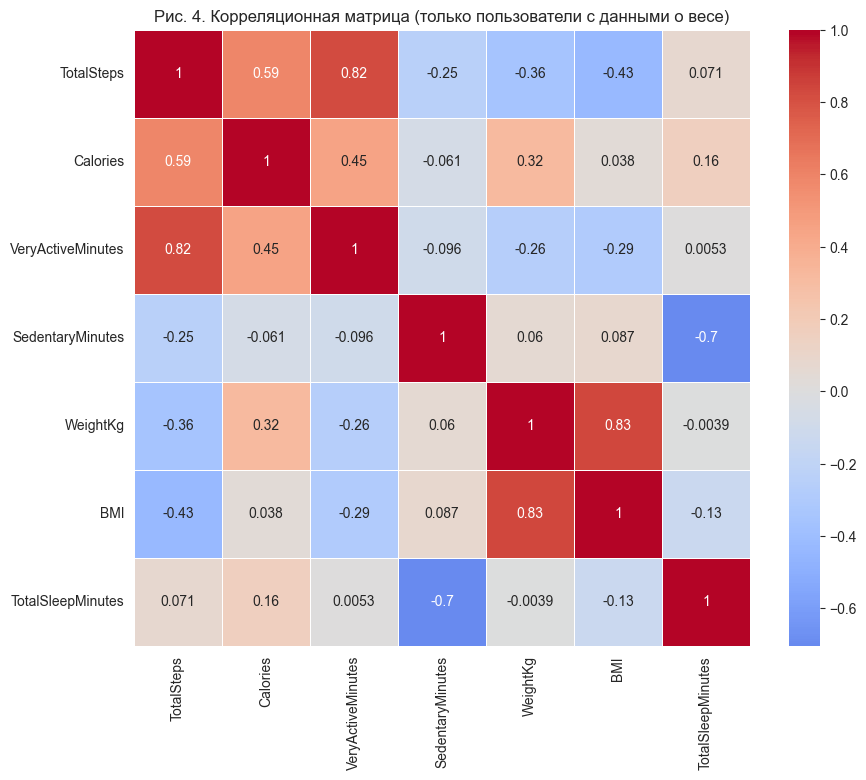

In [5]:
# График 1: Распределение калорий и шагов (на всей выборке)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_merged['Calories'], kde=True, ax=axes[0], color='orange')
axes[0].set_title('Рис. 1. Распределение сожжённых калорий (вся выборка)')

sns.histplot(df_merged['TotalSteps'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Рис. 2. Распределение общего количества шагов (вся выборка)')

plt.tight_layout()
plt.show()

# График 2: Корреляционная матрица (вся выборка)
plt.figure(figsize=(8, 6))
numeric_cols_all = ['TotalSteps', 'Calories', 'VeryActiveMinutes', 'SedentaryMinutes', 'TotalSleepMinutes']
corr_matrix_all = df_merged[numeric_cols_all].corr()
sns.heatmap(corr_matrix_all, annot=True, cmap='coolwarm', center=0, square=True, linewidths=.5)
plt.title('Рис. 3. Корреляционная матрица (вся выборка)')
plt.show()

# График 3: Корреляционная матрица (подвыборка с весом)
plt.figure(figsize=(10, 8))
numeric_cols_filtered = ['TotalSteps', 'Calories', 'VeryActiveMinutes', 'SedentaryMinutes', 'WeightKg', 'BMI', 'TotalSleepMinutes']
corr_matrix_filtered = df_merged_filtered[numeric_cols_filtered].corr()
sns.heatmap(corr_matrix_filtered, annot=True, cmap='coolwarm', center=0, square=True, linewidths=.5)
plt.title('Рис. 4. Корреляционная матрица (только пользователи с данными о весе)')
plt.show()

# 8. Анализ и проверка гипотез

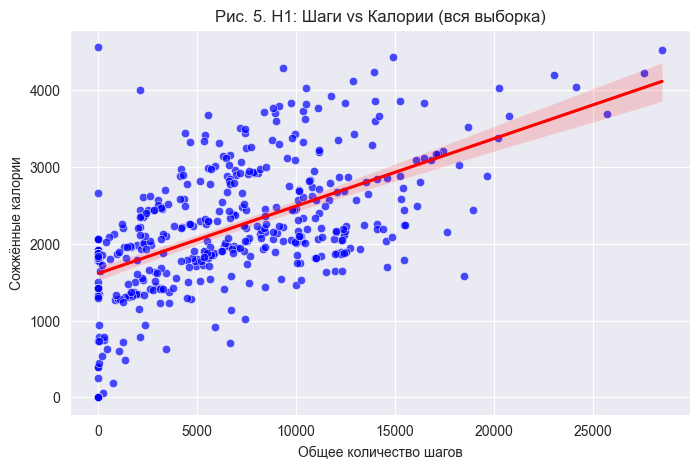

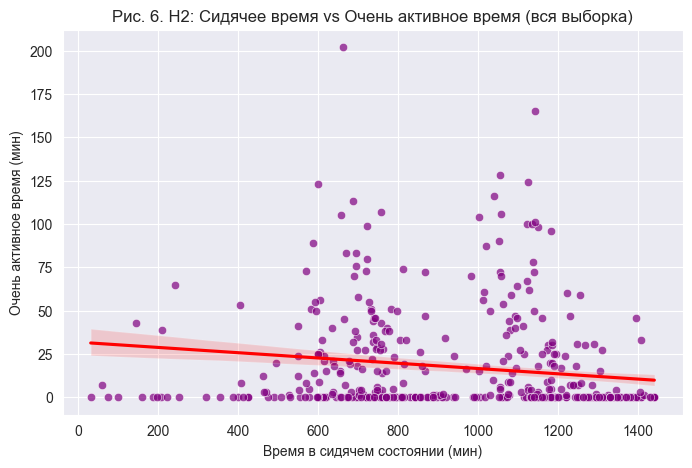

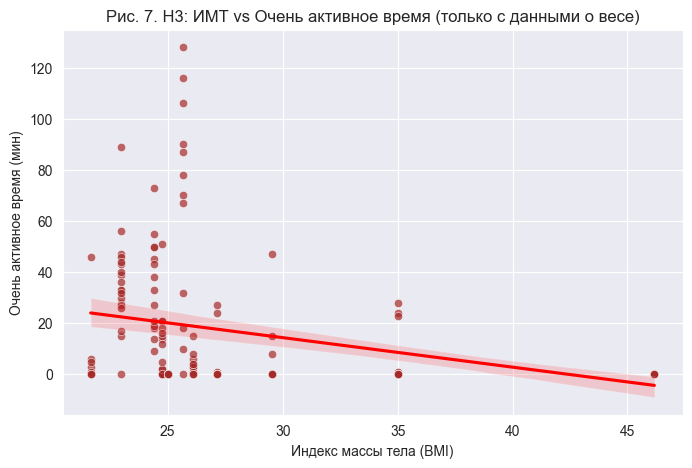

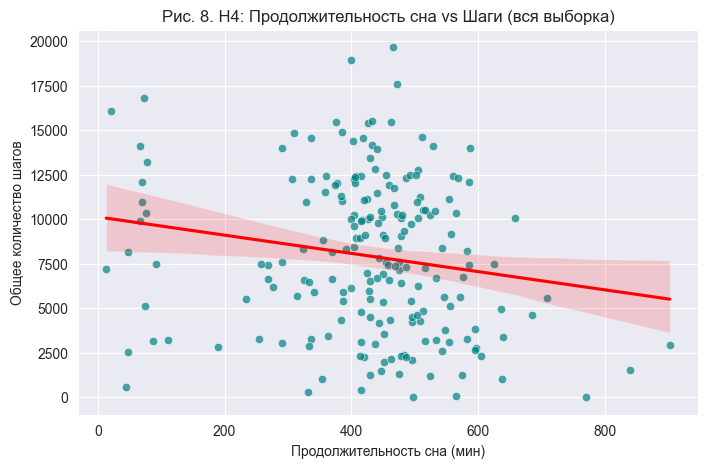

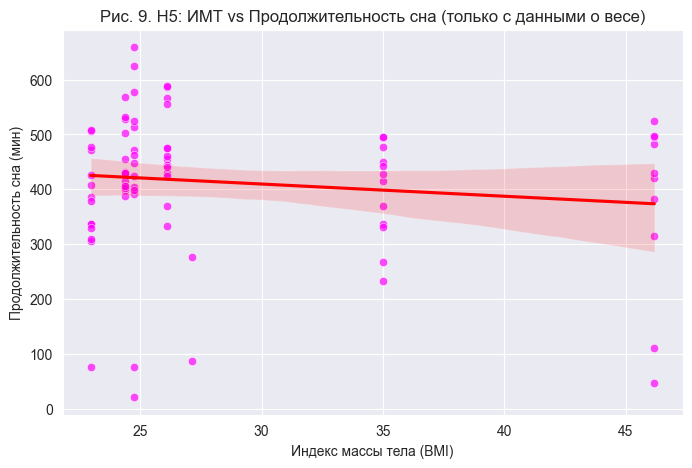

In [6]:
# Гипотеза H1: TotalSteps vs Calories (на всей выборке)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_merged, x='TotalSteps', y='Calories', alpha=0.7, color='blue')
sns.regplot(data=df_merged, x='TotalSteps', y='Calories', scatter=False, color='red')
plt.title('Рис. 5. H1: Шаги vs Калории (вся выборка)')
plt.xlabel('Общее количество шагов')
plt.ylabel('Сожжённые калории')
plt.grid(True)
plt.show()

# Гипотеза H2: SedentaryMinutes vs VeryActiveMinutes (на всей выборке)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_merged, x='SedentaryMinutes', y='VeryActiveMinutes', alpha=0.7, color='purple')
sns.regplot(data=df_merged, x='SedentaryMinutes', y='VeryActiveMinutes', scatter=False, color='red')
plt.title('Рис. 6. H2: Сидячее время vs Очень активное время (вся выборка)')
plt.xlabel('Время в сидячем состоянии (мин)')
plt.ylabel('Очень активное время (мин)')
plt.grid(True)
plt.show()

# Гипотеза H3: BMI vs VeryActiveMinutes (только на подвыборке!)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_merged_filtered, x='BMI', y='VeryActiveMinutes', alpha=0.7, color='brown')
sns.regplot(data=df_merged_filtered, x='BMI', y='VeryActiveMinutes', scatter=False, color='red')
plt.title('Рис. 7. H3: ИМТ vs Очень активное время (только с данными о весе)')
plt.xlabel('Индекс массы тела (BMI)')
plt.ylabel('Очень активное время (мин)')
plt.grid(True)
plt.show()

# Гипотеза H4: TotalSleepMinutes vs TotalSteps (текущий день - на всей выборке)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_merged, x='TotalSleepMinutes', y='TotalSteps', alpha=0.7, color='teal')
sns.regplot(data=df_merged, x='TotalSleepMinutes', y='TotalSteps', scatter=False, color='red')
plt.title('Рис. 8. H4: Продолжительность сна vs Шаги (вся выборка)')
plt.xlabel('Продолжительность сна (мин)')
plt.ylabel('Общее количество шагов')
plt.grid(True)
plt.show()

# Гипотеза H5: BMI vs TotalSleepMinutes (только на подвыборке!)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_merged_filtered, x='BMI', y='TotalSleepMinutes', alpha=0.7, color='magenta')
sns.regplot(data=df_merged_filtered, x='BMI', y='TotalSleepMinutes', scatter=False, color='red')
plt.title('Рис. 9. H5: ИМТ vs Продолжительность сна (только с данными о весе)')
plt.xlabel('Индекс массы тела (BMI)')
plt.ylabel('Продолжительность сна (мин)')
plt.grid(True)
plt.show()